<a href="https://colab.research.google.com/github/flaesant/TesteFla/blob/master/flocking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Boids

In [2]:
### CRIANDO OS BOIDS NO ESPAÇO ESTATICAMENTE ###

import numpy as np

class Boid:
    def __init__(self, x, y, window_width, window_height):
        # A posição atual do boid (x, y)
        self.position = np.array([float(x), float(y)])

        # velocidade aleatória inicial para começar o movimento
        # np.random.uniform gera valores entre -1 e 1 para as direções X e Y
        self.velocity = np.random.uniform(-1, 1, 2)

        # A aceleração começa em zero
        self.acceleration = np.zeros(2)

        # Limites da tela
        self.window_width = window_width
        self.window_height = window_height

    def update(self):
        # 1. A velocidade aumenta com a aceleração
        self.velocity += self.acceleration

        # 2. A posição muda de acordo com a velocidade
        self.position += self.velocity

        # 3. Reiniciar a aceleração para o próximo ciclo
        self.acceleration = np.zeros(2)

In [18]:
### CRIANDO OS BOIDS COM MOVIMENTO ALEATÓRIO ###

import numpy as np

class Boid:
    def __init__(self, x, y, width, height):
        self.position = np.array([float(x), float(y)])
        self.window_width = width
        self.window_height = height

        # Criando uma velocidade aleatória (vetor com x e y entre -1 e 1)
        self.velocity = np.random.uniform(-1, 1, 2)

        # A aceleração começa em zero
        self.acceleration = np.zeros(2)

        # Limites para o movimento parecer natural
        self.max_speed = 100
        self.max_force = 0.3

    def update(self):

        self.position += self.velocity
        self.velocity += self.acceleration

        # Limitar a velocidade (Magnitude do vetor)
        norm = np.linalg.norm(self.velocity)
        if norm > self.max_speed:
            self.velocity = (self.velocity / norm) * self.max_speed

        # Resetar a aceleração para o próximo frame
        self.acceleration = np.zeros(2)

In [27]:
### DEFININDO OS LIMITES DA BORDA PARA O BOID NÃO FICAR "PERDIDO" ###

import numpy as np

class Boid:
    def __init__(self, x, y, window_width, window_height):
        self.position = np.array([float(x), float(y)])
        self.velocity = np.random.uniform(-1, 1, 2)
        self.acceleration = np.zeros(2)
        self.width = window_width
        self.height = window_height

    def edges(self):
        # Verifica o eixo X (Lado direito e esquerdo)
        if self.position[0] > self.width:
            self.position[0] = 0
        elif self.position[0] < 0:
            self.position[0] = self.width

        # Verifica o eixo Y (Topo e fundo)
        if self.position[1] > self.height:
            self.position[1] = 0
        elif self.position[1] < 0:
            self.position[1] = self.height

    ### BOIDS SE MOVEM SEM LIMITES DE VELOCIDADE ###

    #def update(self):
    # Simulando uma força constante (como o vento ou o desejo de se alinhar)
    # self.acceleration = np.array([0.1, 0.05])

    # self.velocity += self.acceleration
    # self.position += self.velocity

    # Sem limite de velocidade
    # self.acceleration = np.zeros(2)

    ### BOIDS SE MOVEM COM LIMITES DE VELOCIDADE - MOVIMENTOS SUAVES ###
    def update(self):
        self.velocity += self.acceleration
        self.position += self.velocity
        self.acceleration = np.zeros(2)



In [29]:
### ADICIONANDO ALINHAMENTO AO MOVIMENTO DOS BOIDS ###

import numpy as np

class Boid:
    def __init__(self, x, y, width, height):
        self.position = np.array([float(x), float(y)])
        self.velocity = np.random.uniform(-1, 1, 2)
        self.acceleration = np.zeros(2)
        self.width = width
        self.height = height

        # Atributos para o Alinhamento
        self.max_speed = 5
        self.max_force = 0.3  # Quão rápido ele consegue virar
        self.perception = 50   # Raio de visão

    def align(self, boids):
        steering = np.zeros(2)
        total = 0
        avg_vec = np.zeros(2)

        for other in boids:
            # Calculamos a distância entre este boid e os outros
            distance = np.linalg.norm(other.position - self.position)

            # Regra: b != bi E dist < raio (Algoritmo de alinhamento)
            if other is not self and distance < self.perception:
                avg_vec += other.velocity
                total += 1

        if total > 0:
            avg_vec /= total  # Média das velocidades

            # Normalizando para a velocidade máxima (Desejo do boid)
            norm = np.linalg.norm(avg_vec)
            if norm > 0:
                avg_vec = (avg_vec / norm) * self.max_speed

            # Cálculo da força de direção (Steering = Desejo - Velocidade Atual)
            steering = avg_vec - self.velocity

            # Limitando a força para a curva ser suave (menos robótica)
            steering_norm = np.linalg.norm(steering)
            if steering_norm > self.max_force:
                steering = (steering / steering_norm) * self.max_force

        return steering

    def apply_behaviour(self, boids):
        alignment = self.align(boids)
        self.acceleration += alignment

    def update(self):
        self.velocity += self.acceleration

        norm = np.linalg.norm(self.velocity)
        if norm > self.max_speed:
            self.velocity = (self.velocity / norm) * self.max_speed

        self.position += self.velocity
        self.acceleration = np.zeros(2)

    def edges(self):
        if self.position[0] > self.width: self.position[0] = 0
        elif self.position[0] < 0: self.position[0] = self.width
        if self.position[1] > self.height: self.position[1] = 0
        elif self.position[1] < 0: self.position[1] = self.height

In [36]:
### ADICIONANDO COESÃO AO MOVIMENTO DOS BOIDS ###

import numpy as np

class Boid:
    def __init__(self, x, y, width, height):
        self.position = np.array([float(x), float(y)])
        self.velocity = np.random.uniform(-1, 1, 2)
        self.acceleration = np.zeros(2)
        self.width = width
        self.height = height

        # Atributos para o Alinhamento
        self.max_speed = 5
        self.max_force = 0.3  # Quão rápido ele consegue virar
        self.perception = 50   # Raio de visão

    def cohesion(self, boids):
      steering = np.zeros(2)
      total = 0
      center_of_mass = np.zeros(2)

      for other in boids:
          distance = np.linalg.norm(other.position - self.position)

          # Regra do slide: b != bi e dist < raio
          if other is not self and distance < self.perception:
              center_of_mass += other.position
              total += 1

      if total > 0:
          center_of_mass /= total  # Encontramos o centro

          # Vetor que aponta da minha posição atual para o centro do grupo
          vec_to_com = center_of_mass - self.position

          # Normalização (Desejo de ir para lá na velocidade máxima)
          dist_to_com = np.linalg.norm(vec_to_com)
          if dist_to_com > 0:
              vec_to_com = (vec_to_com / dist_to_com) * self.max_speed

          # Steering: Desejo - Velocidade Atual (conforme o slide: Ci - bi.velocidade)
          steering = vec_to_com - self.velocity

          # Limite de força para a curva ser suave
          steering_norm = np.linalg.norm(steering)
          if steering_norm > self.max_force:
              steering = (steering / steering_norm) * self.max_force

      return steering

    #def apply_behaviour(self, boids):
      # alignment = self.align(boids)
      #cohesion_force = self.cohesion(boids)

      # self.acceleration += alignment
      #self.acceleration += cohesion_force

    #### Uma alternativa para ver os BOIDS parados caso não tenha ninguem ao seu redor ###

    def apply_behaviour(self, boids):
      cohesion_force = self.cohesion(boids)

    # Se a força de coesão for zero (ninguém por perto),
    # podemos forçar a velocidade a diminuir
      if np.all(cohesion_force == 0):
          self.velocity *= 0.9  # "Fricção": ele vai parando aos poucos
      else:
          self.acceleration += cohesion_force

    def update(self):
      self.velocity += self.acceleration

      norm = np.linalg.norm(self.velocity)
      if norm > self.max_speed:
          self.velocity = (self.velocity / norm) * self.max_speed

      self.position += self.velocity
      self.acceleration = np.zeros(2)

    def edges(self):
        if self.position[0] > self.width: self.position[0] = 0
        elif self.position[0] < 0: self.position[0] = self.width
        if self.position[1] > self.height: self.position[1] = 0
        elif self.position[1] < 0: self.position[1] = self.height

In [40]:
### ADICIONANDO SEPARAÇÃO AO MOVIMENTO DOS BOIDS ###

import numpy as np

class Boid:
    def __init__(self, x, y, width, height):
        self.position = np.array([float(x), float(y)])
        self.velocity = np.random.uniform(-1, 1, 2)
        self.acceleration = np.zeros(2)
        self.width = width
        self.height = height

        # Atributos para o Alinhamento
        self.max_speed = 5
        self.max_force = 0.3  # Quão rápido ele consegue virar
        self.perception = 50   # Raio de visão


    def separation(self, boids):
      steering = np.zeros(2)
      total = 0
      avg_vector = np.zeros(2)

      for other in boids:
          distance = np.linalg.norm(other.position - self.position)
          if other is not self and distance < self.perception:
              diff = self.position - other.position # Vetor de fuga
              if distance > 0:
                  diff /= distance # Quanto mais perto, maior a fuga
              avg_vector += diff
              total += 1

      if total > 0:
          avg_vector /= total
          norm = np.linalg.norm(avg_vector)
          if norm > 0:
              avg_vector = (avg_vector / norm) * self.max_speed

          steering = avg_vector - self.velocity

          # Limita a força para a manobra ser suave
          if np.linalg.norm(steering) > self.max_force:
              steering = (steering / np.linalg.norm(steering)) * self.max_force

      return steering

    def apply_behaviour(self, boids):
      # Calculamos apenas a força de separação
      separation_force = self.separation(boids)

      # Adicionamos a força diretamente à aceleração.
      # Se a força for 0, a aceleração será 0,
      # e o boid manterá sua velocidade atual em linha reta.
      self.acceleration += separation_force

    def update(self):
      self.velocity += self.acceleration

      norm = np.linalg.norm(self.velocity)
      if norm > self.max_speed:
          self.velocity = (self.velocity / norm) * self.max_speed

      self.position += self.velocity
      self.acceleration = np.zeros(2)

    def edges(self):
        if self.position[0] > self.width: self.position[0] = 0
        elif self.position[0] < 0: self.position[0] = self.width
        if self.position[1] > self.height: self.position[1] = 0
        elif self.position[1] < 0: self.position[1] = self.height

In [42]:
### CRIANDO OS BOIDS COM AS 3 REGRAS DE ESTIGMERGIA ###

import numpy as np

class Boid:
    def __init__(self, x, y, width, height):
        self.position = np.array([float(x), float(y)])
        self.velocity = np.random.uniform(-1, 1, 2)
        self.acceleration = np.zeros(2)
        self.width = width
        self.height = height

        # Parâmetros de comportamento
        self.max_speed = 4
        self.max_force = 0.2
        self.perception = 50

    def align(self, boids):
        steering = np.zeros(2)
        total = 0
        avg_vec = np.zeros(2)
        for other in boids:
            distance = np.linalg.norm(other.position - self.position)
            if other is not self and distance < self.perception:
                avg_vec += other.velocity
                total += 1
        if total > 0:
            avg_vec /= total
            norm = np.linalg.norm(avg_vec)
            if norm > 0:
                avg_vec = (avg_vec / norm) * self.max_speed
            steering = avg_vec - self.velocity
            if np.linalg.norm(steering) > self.max_force:
                steering = (steering / np.linalg.norm(steering)) * self.max_force
        return steering

    def cohesion(self, boids):
        steering = np.zeros(2)
        total = 0
        center_of_mass = np.zeros(2)
        for other in boids:
            distance = np.linalg.norm(other.position - self.position)
            if other is not self and distance < self.perception:
                center_of_mass += other.position
                total += 1
        if total > 0:
            center_of_mass /= total
            vec_to_com = center_of_mass - self.position
            norm = np.linalg.norm(vec_to_com)
            if norm > 0:
                vec_to_com = (vec_to_com / norm) * self.max_speed
            steering = vec_to_com - self.velocity
            if np.linalg.norm(steering) > self.max_force:
                steering = (steering / np.linalg.norm(steering)) * self.max_force
        return steering

    def separation(self, boids):
        steering = np.zeros(2)
        total = 0
        avg_vector = np.zeros(2)
        for other in boids:
            distance = np.linalg.norm(other.position - self.position)
            if other is not self and distance < self.perception:
                diff = self.position - other.position
                if distance > 0:
                    diff /= distance
                avg_vector += diff
                total += 1
        if total > 0:
            avg_vector /= total
            norm = np.linalg.norm(avg_vector)
            if norm > 0:
                avg_vector = (avg_vector / norm) * self.max_speed
            steering = avg_vector - self.velocity
            if np.linalg.norm(steering) > self.max_force:
                steering = (steering / np.linalg.norm(steering)) * self.max_force
        return steering

    def apply_behaviour(self, boids):
        # Aqui juntamos as 3 forças!
        self.acceleration += self.align(boids)
        self.acceleration += self.cohesion(boids)
        self.acceleration += self.separation(boids)

    def update(self):
        self.velocity += self.acceleration
        norm = np.linalg.norm(self.velocity)
        if norm > self.max_speed:
            self.velocity = (self.velocity / norm) * self.max_speed
        self.position += self.velocity
        self.acceleration = np.zeros(2)

    def edges(self):
        if self.position[0] > self.width: self.position[0] = 0
        elif self.position[0] < 0: self.position[0] = self.width
        if self.position[1] > self.height: self.position[1] = 0
        elif self.position[1] < 0: self.position[1] = self.height



# Main.py

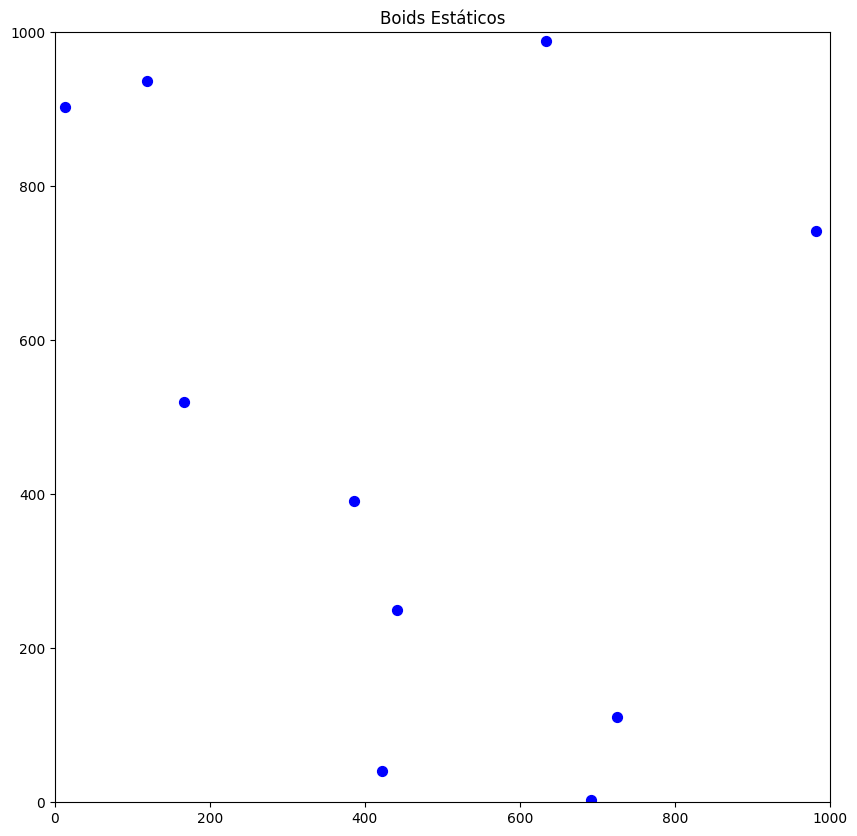

In [5]:
### CRIANDO OS BOIDS NO ESPAÇO ESTATICAMENTE ###
import matplotlib.pyplot as plt

width, height = 1000, 1000
n_boids = 10

# Criando boids em posições aleatórias (Setup)
flock = [Boid(np.random.rand()*width, np.random.rand()*height, width, height) for _ in range(n_boids)]

# Visualizando (equivalente ao Show/Draw inicial)
plt.figure(figsize=(10,10))
x_coords = [b.position[0] for b in flock]
y_coords = [b.position[1] for b in flock]

plt.scatter(x_coords, y_coords, color='blue', s=50) # s=50 é o tamanho do círculo (radius)
plt.xlim(0, width)
plt.ylim(0, height)
plt.title("Boids Estáticos")
plt.show()

In [14]:
### ADICIONANDO MOVIMENTO AOS BOIDS "DESCONTROLADOS" ###
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# --- CONFIGURAÇÃO INICIAL  (equivalente ao "Setup") ---
width, height = 1000, 1000
n_boids = 30  # poucos boids para testar a performance

# lista de boids
flock = [Boid(np.random.rand()*width, np.random.rand()*height, width, height) for _ in range(n_boids)]

# Configuração da visualização do Matplotlib
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, width)
ax.set_ylim(0, height)

# O objeto "ponto" que representará os boids no gráfico
scat = ax.scatter([b.position[0] for b in flock],
                  [b.position[1] for b in flock],
                  s=10, c='blue')

# --- FUNÇÃO DE ATUALIZAÇÃO (equivalente ao "draw") ---
def animate(frame):
    # Lista para armazenar as novas posições
    x_data = []
    y_data = []

    for boid in flock:
        boid.update()  # Chama o método que criámos na Etapa 1
        x_data.append(boid.position[0])
        y_data.append(boid.position[1])

    # Atualiza a posição dos pontos no gráfico
    scat.set_offsets(np.c_[x_data, y_data])
    return scat,

# --- EXECUÇÃO (Equivalente ao "run") ---
# Criando a animação (100 frames para começar)
ani = animation.FuncAnimation(fig, animate, frames=300, interval=50, blit=True)

# Fecha o gráfico estático para não duplicar a imagem
plt.close()

# Renderiza a animação como um vídeo HTML5 compatível com Colab
HTML(ani.to_html5_video())

In [28]:
### DEFININDO OS LIMITES DA BORDA PARA O BOID NÃO FICAR "PERDIDO" ###
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# --- CONFIGURAÇÃO INICIAL  (equivalente ao "Setup") ---
width, height = 1000, 1000
n_boids = 30  # poucos boids para testar a performance

# lista de boids
flock = [Boid(np.random.rand()*width, np.random.rand()*height, width, height) for _ in range(n_boids)]

# Configuração da visualização do Matplotlib
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, width)
ax.set_ylim(0, height)

# O objeto "ponto" que representará os boids no gráfico
scat = ax.scatter([b.position[0] for b in flock],
                  [b.position[1] for b in flock],
                  s=10, c='blue')

def animate(frame):
    x_data = []
    y_data = []

    for boid in flock:
        boid.edges()   # <--- Verifica as bordas primeiro
        boid.update()  # <--- Move o boid
        x_data.append(boid.position[0])
        y_data.append(boid.position[1])

    scat.set_offsets(np.c_[x_data, y_data])
    return scat,

# --- EXECUÇÃO (Equivalente ao "run") ---
# Criando a animação (100 frames para começar)
ani = animation.FuncAnimation(fig, animate, frames=300, interval=50, blit=True)

# Fecha o gráfico estático para não duplicar a imagem
plt.close()

# Renderiza a animação como um vídeo HTML5 compatível com Colab
HTML(ani.to_html5_video())

In [41]:
### MOVIMENTO DOS BOIDS SEGUNDO A REGRA ISOLADAS DE ALINHAMENTO, COESÃO E SEPARAÇÃO ###
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# --- CONFIGURAÇÃO INICIAL  (equivalente ao "Setup") ---
width, height = 1000, 1000
n_boids = 30  # poucos boids para testar a performance

# lista de boids
flock = [Boid(np.random.rand()*width, np.random.rand()*height, width, height) for _ in range(n_boids)]

# Configuração da visualização do Matplotlib
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, width)
ax.set_ylim(0, height)

# O objeto "ponto" que representará os boids no gráfico
scat = ax.scatter([b.position[0] for b in flock],
                  [b.position[1] for b in flock],
                  s=10, c='blue')

def animate(frame):
    x_data = []
    y_data = []

    for boid in flock:
        boid.apply_behaviour(flock) # Calcula as forças sociais
        boid.update()               # Aplica a física
        boid.edges()                # Checa as bordas

        x_data.append(boid.position[0])
        y_data.append(boid.position[1])

    scat.set_offsets(np.c_[x_data, y_data])
    return scat,

    # --- EXECUÇÃO (Equivalente ao "run") ---
# Criando a animação (100 frames para começar)
ani = animation.FuncAnimation(fig, animate, frames=300, interval=50, blit=True)

# Fecha o gráfico estático para não duplicar a imagem
plt.close()

# Renderiza a animação como um vídeo HTML5 compatível com Colab
HTML(ani.to_html5_video())

In [45]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Configurações do experimento
width, height = 1000, 1000
n_boids = 40

# Setup inicial
flock = [Boid(np.random.rand()*width, np.random.rand()*height, width, height) for _ in range(n_boids)]

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, width)
ax.set_ylim(0, height)
ax.set_facecolor('#1e1e2f')  # Fundo escuro como no tutorial

scat = ax.scatter([b.position[0] for b in flock],
                  [b.position[1] for b in flock],
                  s=20, c='cyan', edgecolors='white', linewidths=0.5)

def animate(frame):
    x_data = []
    y_data = []

    for boid in flock:
        boid.apply_behaviour(flock)
        boid.update()
        boid.edges()
        x_data.append(boid.position[0])
        y_data.append(boid.position[1])

    scat.set_offsets(np.c_[x_data, y_data])
    return scat,

# Criar animação
ani = animation.FuncAnimation(fig, animate, frames=300, interval=60, blit=True)
plt.close()

# Mostrar o resultado
HTML(ani.to_html5_video())